In [15]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling, unfocus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

# Making a Forward Model

## Configure a DM

In [16]:
# First we need a forward model of the system
# NOTE: Influence functions should peak at 1

# Basic inputs to a prysm DM
# - influence function
# - number of actuators in X and Y axes
# - separation of the actuators in the array containing the lattice, in units of samples

nact = 11
act_pitch = 6
samples_per_act = 42
sampling_pitch = act_pitch / samples_per_act

x, y = make_xy_grid(512, dx=sampling_pitch)
r, th = cart_to_polar(x, y)
influence_func = gaussian_influence_function(r, act_pitch)#np.sinc(x/act_pitch) * np.sinc(y/act_pitch)
# influence_func /= np.max(influence_func)
Nout = x.shape[0]
dm = DM(influence_func, Nout, nact, samples_per_act, rot=(0,0,0), shift=(samples_per_act, samples_per_act))

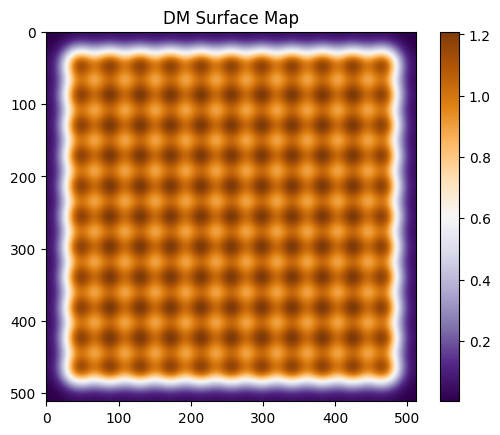

In [17]:
dm.actuators[:] = 1
sfe = dm.render(wfe=False)
plt.title("DM Surface Map")
plt.imshow(sfe, cmap="PuOr_r")
plt.colorbar()
dm.actuators[:] = 0

## Configure Wavefront Error

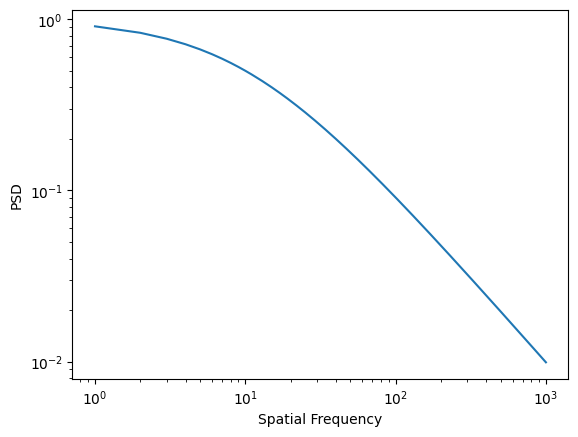

In [18]:
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=1, b=10, c=1)

plt.figure()
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.show()

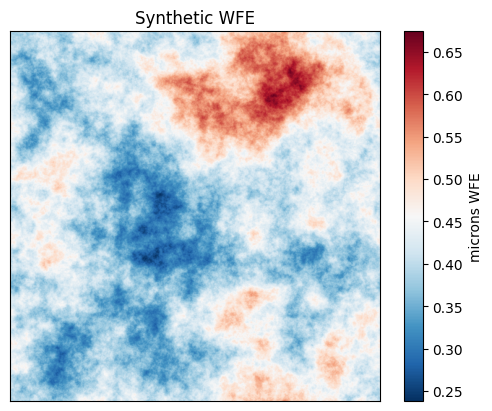

In [19]:
# Just picked ABC values until it looked about right
Npup = Nout
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

plt.figure()
plt.title('Synthetic WFE')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

## Configure Diffraction Model

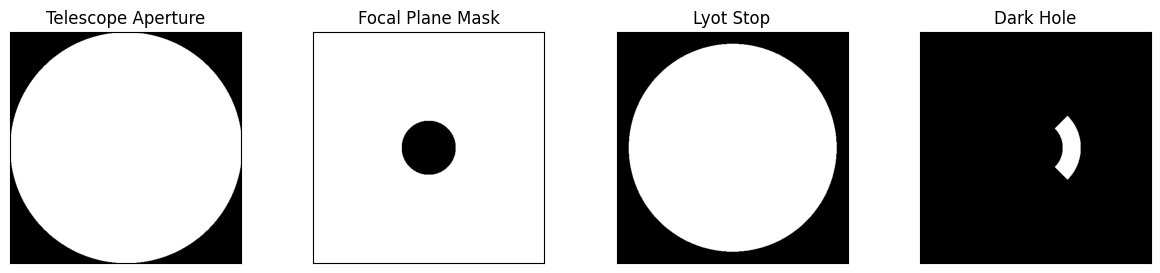

In [20]:
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)
A = circle(1, r)
LS = circle(0.9, r)

# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1/2 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL * z) # with error

# Sample field
focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
IWA = 3
OWA = 5
CORO_IWA = 3
dark_hole[rho < OWA] = 1
dark_hole[rho < IWA] = 0
dark_hole[psi < -np.pi / 4] = 0
dark_hole[psi > np.pi / 4] = 0

FPM = np.ones_like(u)
FPM[ rho < CORO_IWA] = 0

focal_intensity = np.abs(focal)**2

plt.figure(figsize=[15,3])
plt.subplot(141)
plt.imshow(A, cmap='gray')
plt.xticks([],[])
plt.yticks([],[])
plt.title('Telescope Aperture')
plt.subplot(142)
plt.imshow(FPM, cmap='gray')
plt.title('Focal Plane Mask')
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(143)
plt.imshow(LS, cmap='gray')
plt.title('Lyot Stop')
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(144)
plt.imshow(dark_hole, cmap='gray')
plt.title('Dark Hole')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

In [21]:
def snap_image(pupil_wfe=np.zeros_like(A), include_fpm=True):
    """take intensity image given a pupil wfe in microns

    Parameters
    ----------
    pupil_wfe : ndarray, optional
        wavefront error in microns, by default np.ones_like(A)
    """

    # create nominal wavefront
    wfe = np.exp(1j * 2 * np.pi / WVL * pupil_wfe)
    wvfnt_to_prop = wfe * wvfnt

    # propagate to focus
    focal = focus_fixed_sampling(wvfnt_to_prop,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    if include_fpm:
        focal *= FPM

    lyot = unfocus_fixed_sampling(focal,
                                input_dx=dx_img, # um
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=Dpup / wvfnt.shape[0], # mm
                                output_samples=wvfnt.shape[0])
    
    lyot *= LS

    coro = focus_fixed_sampling(lyot,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    return np.abs(coro)**2


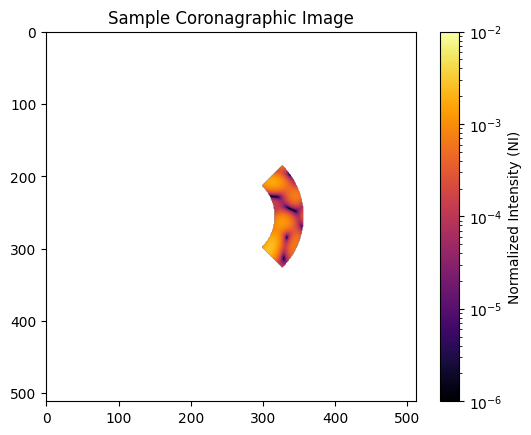

In [22]:
ref_contrast = snap_image(include_fpm=False).max()

plt.figure()
plt.title("Sample Coronagraphic Image")
plt.imshow(snap_image() / ref_contrast * dark_hole, cmap='inferno', norm=LogNorm(vmin=1e-6, vmax=1e-2))
plt.colorbar(label="Normalized Intensity (NI)")
plt.show()

# Speckle Nulling

In [23]:
from poi.speckle_nulling import SpeckleNulling

sn = SpeckleNulling(propagation=snap_image,
                    dx_img=dx_img,
                    epd=Dpup,
                    efl=EFL,
                    wvl=WVL,
                    dm=dm, 
                    dh=dark_hole,
                    ref_contrast=ref_contrast)

## Apply Waffle Pattern at maximum DM frequency

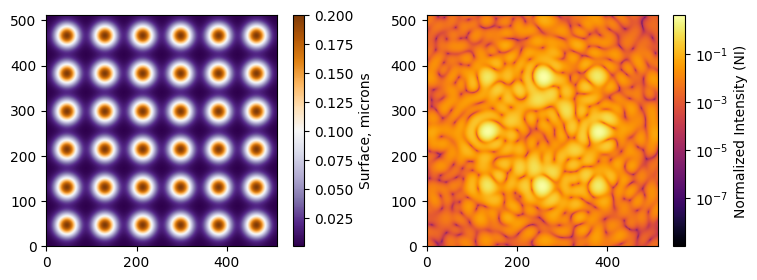

In [24]:
waffle_image, waffle_dm = sn.get_image_center()

plt.figure(figsize=[9,3])
plt.subplot(121)
plt.imshow(waffle_dm, cmap="PuOr_r", origin="lower")
plt.colorbar(label="Surface, microns")
plt.subplot(122)
plt.imshow(waffle_image, cmap="inferno", norm=LogNorm(), origin="lower")
plt.colorbar(label="Normalized Intensity (NI)")
plt.show()

## Step speckle nulling

In [25]:
from poi.processing import azimuthal_average

In [26]:
MAX_ITERS = 25 # roughly equals total number of images taken with iEFC
images_sn = []
profiles = []
for _ in range(MAX_ITERS):
    img = sn.step()
    images_sn.append(img)
    pro, bins = azimuthal_average(img)
    profiles.append(pro)

Taking starter image at position zero


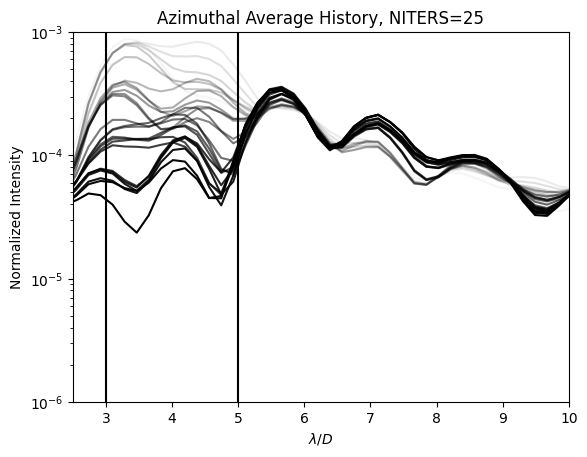

In [28]:
plt.figure()
plt.title(f"Azimuthal Average History, NITERS={MAX_ITERS}")
for i, pro in enumerate(profiles):
    plt.plot(bins * sn.image_dx_lamD, pro / ref_contrast, color="k", alpha=(1/MAX_ITERS)*(i+1))
plt.yscale("log")
plt.ylabel("Normalized Intensity")
plt.xlabel(r"$\lambda / D$")
plt.vlines(IWA, ymin=1e-7, ymax=1e-2, colors="k")
plt.vlines(OWA, ymin=1e-7, ymax=1e-2, colors="k")
plt.ylim([1e-6, 1e-3])
plt.xlim([2.5, 10])
plt.show()

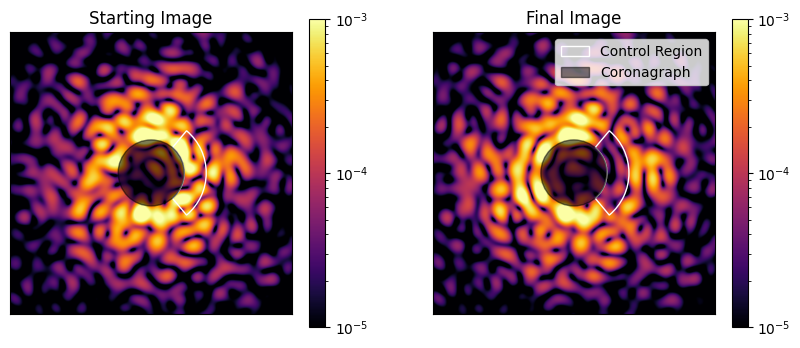

In [29]:
from matplotlib.patches import Wedge, Circle

plt.figure(figsize=[10,4])
plt.subplot(121)
plt.title("Starting Image")
plt.imshow(sn.images[0] / ref_contrast, cmap="inferno", norm=LogNorm(vmax=1e-3, vmin=1e-5), origin="lower")
plt.colorbar()
plt.xticks([],[])
plt.yticks([],[])
# add shadows

# set up dark hole + fpm patches
scale = Dpup / dx_img / WVL
dh_region = 0
dh_region = Wedge((256, 256), r= OWA * scale, width=(OWA - IWA) * scale,
                theta1=-50, theta2=50, # remember these are in degrees
                facecolor="None", edgecolor="w",
                label="Control Region")

fpm_region = Circle((256, 256), CORO_IWA * scale, alpha=0.5, color='k', label="Coronagraph")
ax = plt.gca()
ax.add_patch(dh_region)
ax.add_patch(fpm_region)

plt.subplot(122)
plt.title("Final Image")
plt.imshow(sn.images[-1] / ref_contrast, cmap="inferno", norm=LogNorm(vmax=1e-3, vmin=1e-5), origin="lower")
plt.colorbar()
plt.xticks([],[])
plt.yticks([],[])
dh_region = Wedge((256, 256), r= OWA * scale, width=(OWA - IWA) * scale,
                theta1=-50, theta2=50, # remember these are in degrees
                facecolor="None", edgecolor="w",
                label="Control Region")

fpm_region = Circle((256, 256), CORO_IWA * scale, alpha=0.5, color='k', label="Coronagraph")
ax = plt.gca()
ax.add_patch(dh_region)
ax.add_patch(fpm_region)
plt.legend()
plt.show()

# Implicit Electric Field Conjugation

In [30]:
# Set up a new DM
nact = 11
act_pitch = 6
samples_per_act = 42
sampling_pitch = act_pitch / samples_per_act

x, y = make_xy_grid(512, dx=sampling_pitch)
r, th = cart_to_polar(x, y)
influence_func = gaussian_influence_function(r, act_pitch)#np.sinc(x/act_pitch) * np.sinc(y/act_pitch)
# influence_func /= np.max(influence_func)
Nout = x.shape[0]
dm = DM(influence_func, Nout, nact, samples_per_act, rot=(0,0,0), shift=(samples_per_act, samples_per_act))

In [31]:
from poi.modes import poke_mode_sequence

xact, yact = make_xy_grid(nact, dx=act_pitch)
rhoact, thact = cart_to_polar(xact, yact)
circ_dm_mask = np.ones_like(xact)

modes = poke_mode_sequence(circ_dm_mask)

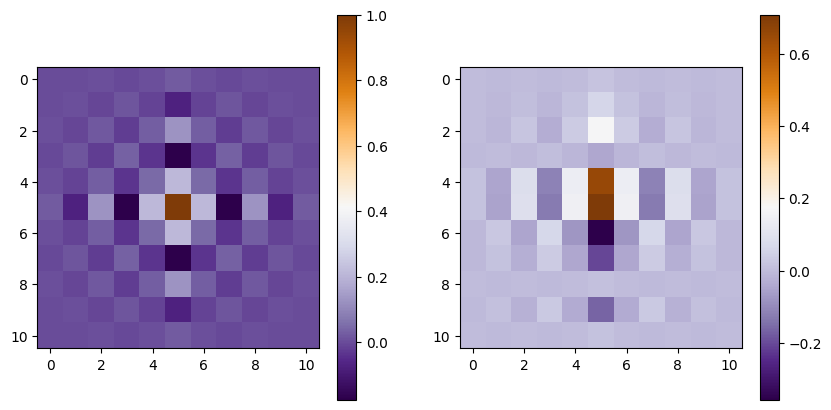

In [32]:
from poi.probes import create_sinc_probe, create_fourier_probes

amp = 1
probe_radius = 4.5 # is this L/D ?
shift = (0, 0)

dm_mask = np.ones([nact, nact])

probe1 = create_sinc_probe(Nacts=nact,
                          amp=amp,
                          probe_radius=probe_radius)

probe2 = create_sinc_probe(Nacts=nact,
                          amp=amp,
                          probe_radius=probe_radius,
                          offset=shift,
                          probe_phase=np.pi / 4)

# probe1, probe2 = create_fourier_probes(dm_mask, 256, dx_img * um_to_LD, iwa=IWA, owa=OWA)

# probe1 = np.zeros_like(probe1)
# probe1[5,5] = 1
# probe2 = np.zeros_like(probe2)
# probe2[5,7] = 1


plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.imshow(probe1, cmap="PuOr_r")
plt.colorbar()
plt.subplot(122)
plt.imshow(probe2, cmap="PuOr_r")
plt.colorbar()
plt.show()

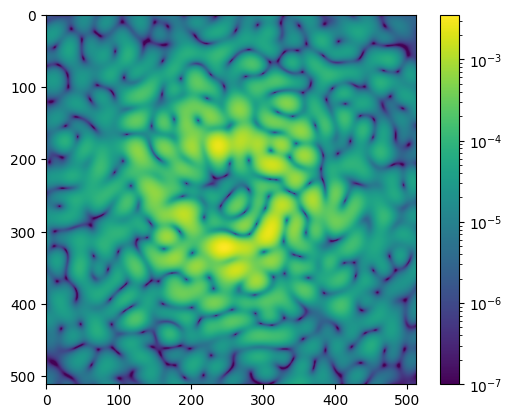

In [33]:
ref_contrast = snap_image(include_fpm=False)
ref_contrast = ref_contrast.max()

plt.imshow(snap_image() / ref_contrast, norm=LogNorm(vmin=1e-7))
plt.colorbar()

In [34]:
from poi.efc import iEFC

iefc = iEFC(snap_image, dm, modes, [probe1, probe2], dark_hole,
            probe_amplitude=20e-3, # radians, change to 20nm
            mode_amplitude=20e-3,
            ref_contrast=ref_contrast)

In [35]:
# try step forward
energy = []
mean_in_dh = []
images = []
betas = np.ones(4) * -2.5
amplitudes = np.array([10, 1, 1., 1., 1.]) * 1e-3
gains = [1, 0.1, 0.1, 0.1, 0.1]
recompute_jacobian = [0, 1, 2]
profiles = []
for i in range(1):
    if i in recompute_jacobian:
        iefc.calibrate()
        iefc.compute_control_matrix(beta=betas[i])
    img = iefc.step(loop_gain=gains[i])
    pro, bins = azimuthal_average(img)
    profiles.append(pro)

    # NOTE: Investigate whether this is actually changing
    iefc.probe_amplitude = amplitudes[i]
    iefc.mode_amplitude = amplitudes[i]

121it [02:01,  1.01s/it]


Taking starter image at position zero


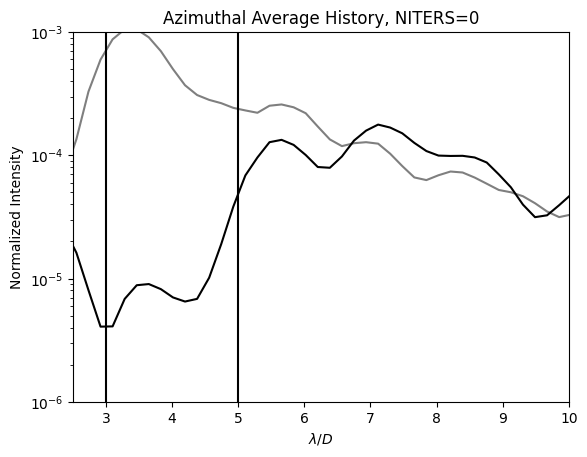

In [36]:
plt.figure()
plt.title(f"Azimuthal Average History, NITERS={i}")
starter_pro, bins = azimuthal_average(iefc.images[0])
plt.plot(bins * sn.image_dx_lamD, starter_pro, color="k", alpha=1/2)
plt.plot(bins * sn.image_dx_lamD, pro, color="k", alpha=1)
plt.yscale("log")
plt.ylabel("Normalized Intensity")
plt.xlabel(r"$\lambda / D$")
plt.vlines(IWA, ymin=1e-7, ymax=1e-2, colors="k")
plt.vlines(OWA, ymin=1e-7, ymax=1e-2, colors="k")
plt.ylim([1e-6, 1e-3])
plt.xlim([2.5, 10])
plt.show()

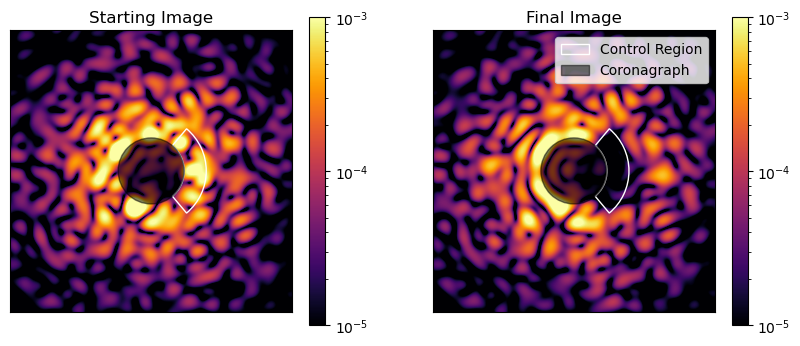

In [ ]:
from matplotlib.patches import Wedge, Circle

plt.figure(figsize=[10,4])
plt.subplot(121)
plt.title("Starting Image")
plt.imshow(iefc.images[0], cmap="inferno", norm=LogNorm(vmax=1e-3, vmin=1e-5), origin="lower")
plt.colorbar()
plt.xticks([],[])
plt.yticks([],[])
# add shadows

# set up dark hole + fpm patches
scale = Dpup / dx_img / WVL
dh_region = 0
dh_region = Wedge((256, 256), r= OWA * scale, width=(OWA - IWA) * scale,
                theta1=-50, theta2=50, # remember these are in degrees
                facecolor="None", edgecolor="w",
                label="Control Region")

fpm_region = Circle((256, 256), CORO_IWA * scale, alpha=0.5, color='k', label="Coronagraph")
ax = plt.gca()
ax.add_patch(dh_region)
ax.add_patch(fpm_region)

plt.subplot(122)
plt.title("Final Image")
plt.imshow(iefc.images[-1], cmap="inferno", norm=LogNorm(vmax=1e-3, vmin=1e-5), origin="lower")
plt.colorbar()
plt.xticks([],[])
plt.yticks([],[])
dh_region = Wedge((256, 256), r= OWA * scale, width=(OWA - IWA) * scale,
                theta1=-50, theta2=50, # remember these are in degrees
                facecolor="None", edgecolor="w",
                label="Control Region")

fpm_region = Circle((256, 256), CORO_IWA * scale, alpha=0.5, color='k', label="Coronagraph")
ax = plt.gca()
ax.add_patch(dh_region)
ax.add_patch(fpm_region)
plt.legend()
vmin = plt.show()

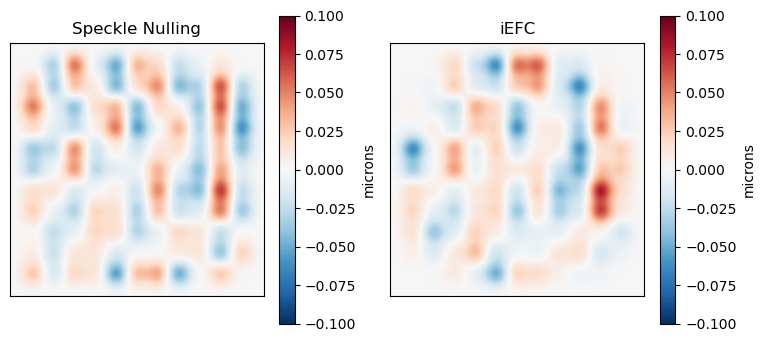

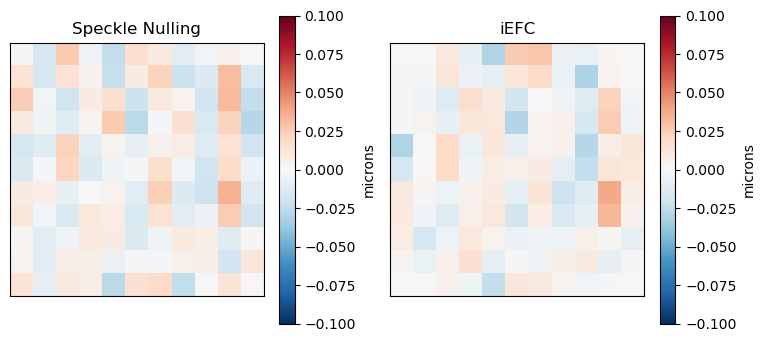

In [ ]:
vmin=-0.1
vmax=0.1

plt.figure(figsize=[9,4])
plt.subplot(121)
plt.title("Speckle Nulling")
plt.imshow(sn.dm.render(), cmap="RdBu_r", vmin=vmin, vmax=vmax)
plt.colorbar(label="microns")
plt.xticks([],[])
plt.yticks([],[])

plt.subplot(122)
plt.title("iEFC")
plt.imshow(iefc.dm.render(), cmap="RdBu_r", vmin=vmin, vmax=vmax)
plt.colorbar(label="microns")
plt.xticks([],[])
plt.yticks([],[])
plt.show()

plt.figure(figsize=[9,4])
plt.subplot(121)
plt.title("Speckle Nulling")
plt.imshow(sn.dm.actuators, cmap="RdBu_r", vmin=vmin, vmax=vmax)
plt.colorbar(label="microns")
plt.xticks([],[])
plt.yticks([],[])

plt.subplot(122)
plt.title("iEFC")
plt.imshow(iefc.dm.actuators, cmap="RdBu_r", vmin=vmin, vmax=vmax)
plt.colorbar(label="microns")
plt.xticks([],[])
plt.yticks([],[])
plt.show()